# MassSpecGym S4 retrieval candidates — analysis

Comprehensive analysis of the S4-generated formula + mass retrieval candidate sets
for MassSpecGym v1.5, produced by `scripts/build_msg_s4_candidates.py`
(`expmisc004_msg_s4_candidates`).

**Pipeline summary**
- ChEMBL31 pretrain reused from MERLIN run (`experiments/data_builds/MERLIN_Apr2026/s4/ckpt_pretrain`).
- S4 fine-tuned **only on MSG-train SMILES** (16,861 mols after dropping 5,877 with OOV tokens vs ChEMBL vocab) — no val/test leakage.
- 200M raw samples across T ∈ {0.7, 1.0, 1.2}, sampled by 8 parallel SLURM tasks.
- Standardisation: pool & queries canonicalised via `massspecgym.utils.rdkit_canonical_smiles`, then **stereo-stripped** in the emit stage (`Chem.MolToSmiles(..., isomericSmiles=False)`).
- **Per-query dedup is now by 2D-InChIKey** (not SMILES-string equality), so candidates with the same 2D structure as the query — including tautomers / surviving stereoisomers — are excluded.
- Final pool: 64.2M unique 2D-InChIKeys, 1.47M unique formulas.
- Trim: 1024 cap per query, uniform-random — applied **after** stereo-strip and dedup, so every list is guaranteed unique by 2D-InChIKey.

**Inputs**
- `experiments/data_builds/MassSpecGym_S4/extract_unique_mols.parquet`
- `experiments/data_builds/MassSpecGym_S4/buckets.parquet`
- `experiments/data_builds/MassSpecGym_S4/samples/temp_*/shard_*.parquet`
- `MassSpecGym/data/MassSpecGym_S4_retrieval_candidates_{formula,mass}_nostereo.json`
- `MassSpecGym/data/MassSpecGym_retrieval_candidates_{formula,mass}.json` (existing PubChem-derived baselines)

In [1]:
import json
import time
import random
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyarrow.parquet as pq
from rdkit import Chem, RDLogger
from rdkit.Chem import rdMolDescriptors, AllChem
from rdkit.DataStructs import BulkTanimotoSimilarity
from rdkit.Chem.Draw import MolsToGridImage
from rdkit.Chem.Scaffolds import MurckoScaffold
from IPython.display import Image as _IPImage, display
RDLogger.DisableLog('rdApp.*')

S4_DIR = Path('/pfs/lustrep2/scratch/project_465002061/rbushuie/DreaMS-Mol_dev/experiments/data_builds/MassSpecGym_S4')
FIG_DIR = Path('/pfs/lustrep2/scratch/project_465002061/rbushuie/DreaMS-Mol_dev/MassSpecGym/notebooks/massspecgym_in_the_wild/figures_s4_candidates')
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Pipeline now writes stereo-stripped, 2D-InChIKey-unique candidates directly to *_nostereo.json paths.
S4_FORMULA_JSON = Path('/pfs/lustrep2/scratch/project_465002061/rbushuie/DreaMS-Mol_dev/MassSpecGym/data/MassSpecGym_S4_retrieval_candidates_formula_nostereo.json')
S4_MASS_JSON    = Path('/pfs/lustrep2/scratch/project_465002061/rbushuie/DreaMS-Mol_dev/MassSpecGym/data/MassSpecGym_S4_retrieval_candidates_mass_nostereo.json')
PUBCHEM_FORMULA_JSON = Path('/pfs/lustrep2/scratch/project_465002061/rbushuie/DreaMS-Mol_dev/MassSpecGym/data/MassSpecGym_retrieval_candidates_formula.json')
PUBCHEM_MASS_JSON    = Path('/pfs/lustrep2/scratch/project_465002061/rbushuie/DreaMS-Mol_dev/MassSpecGym/data/MassSpecGym_retrieval_candidates_mass.json')

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['DejaVu Sans', 'Liberation Sans', 'Arial', 'Helvetica'],
    'font.size': 9, 'axes.labelsize': 9, 'axes.titlesize': 10,
    'legend.fontsize': 8, 'xtick.labelsize': 8, 'ytick.labelsize': 8,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'axes.axisbelow': True,
    'grid.color': '#DDDDDD', 'grid.linewidth': 0.5, 'grid.alpha': 0.8,
    'figure.dpi': 150, 'savefig.dpi': 300, 'savefig.bbox': 'tight',
})

S4_COLOR = '#D95F5F'
PUBCHEM_COLOR = '#6A889F'
POOL_COLOR = '#F2D249'


def _despine(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='both', which='both', direction='out', length=3)


def _save(fig, name):
    fig.savefig(FIG_DIR / f'{name}.png')
    fig.savefig(FIG_DIR / f'{name}.svg')

## 1 — Sample-level validity (per shard sample)

What fraction of raw S4 strings parse via RDKit? Reported per temperature on a sub-sample of shards.

In [2]:
shard_paths = sorted(S4_DIR.glob('samples/temp_*/shard_*.parquet'))
print(f'sample shards: {len(shard_paths)}')


def _temp_from(p):
    return float(p.parent.name.replace('temp_', ''))


N_PER_SHARD = 2000  # 2k/shard × 1008 shards × ratio = ~2M parses; fast
rng = np.random.RandomState(0)
rows = []
for p in shard_paths:
    df = pd.read_parquet(p, columns=['smiles', 'log_likelihood', 'temperature'])
    samp = df.sample(n=min(N_PER_SHARD, len(df)), random_state=rng)
    rows.append({
        'temperature': _temp_from(p),
        'n_raw': len(df),
        'n_sampled': len(samp),
        'n_parse_sampled': int(samp['smiles'].map(lambda s: Chem.MolFromSmiles(s) is not None).sum()),
    })
df_validity = pd.DataFrame(rows).groupby('temperature').sum().reset_index()
df_validity['parse_rate'] = df_validity['n_parse_sampled'] / df_validity['n_sampled']
df_validity

sample shards: 1008


,temperature,n_raw,n_sampled,n_parse_sampled,parse_rate
0,0.7,66666672,672000,662956,0.986542
1,1.0,66666672,672000,641519,0.954641
2,1.2,66666672,672000,612955,0.912135


In [3]:
buckets = pd.read_parquet(S4_DIR / 'buckets.parquet')
n_pool = len(buckets)
n_raw_total = sum(pq.read_metadata(p).num_rows for p in shard_paths)
print(f'raw sampled: {n_raw_total:,}')
print(f'in pool (post-canon + dedup by 2D-InChIKey): {n_pool:,}')
print(f'overall pool/raw rate: {n_pool/n_raw_total*100:.2f}%')
print(f'unique formulas in pool: {buckets["formula"].nunique():,}')

raw sampled: 200,000,016
in pool (post-canon + dedup by 2D-InChIKey): 64,205,194
overall pool/raw rate: 32.10%


unique formulas in pool: 1,470,580


## 1a — Per-temperature quality breakdown

Per-temperature comparison of validity, diversity, and chemical-quality metrics. Makes the temperature trade-off explicit. Sampled diagnostics on 15k raw rows per temperature.

,n_raw,n_pool_attributed,pool_yield,parse_rate,frac_disconnected,frac_nonzero_charge,mean_heavy_atoms,mean_log_likelihood,unique_ik2d_frac_in_sample
temperature,,,,,,,,,
0.7,66666672,8330299,0.1250,0.9876,0.0,0.0005,27.8055,-0.3117,0.6686
1.0,66666672,23751373,0.3563,0.9551,0.0,0.0013,25.2546,-0.4384,0.9117
1.2,66666672,32123522,0.4819,0.9122,0.0,0.0042,24.3127,-0.5406,0.9638


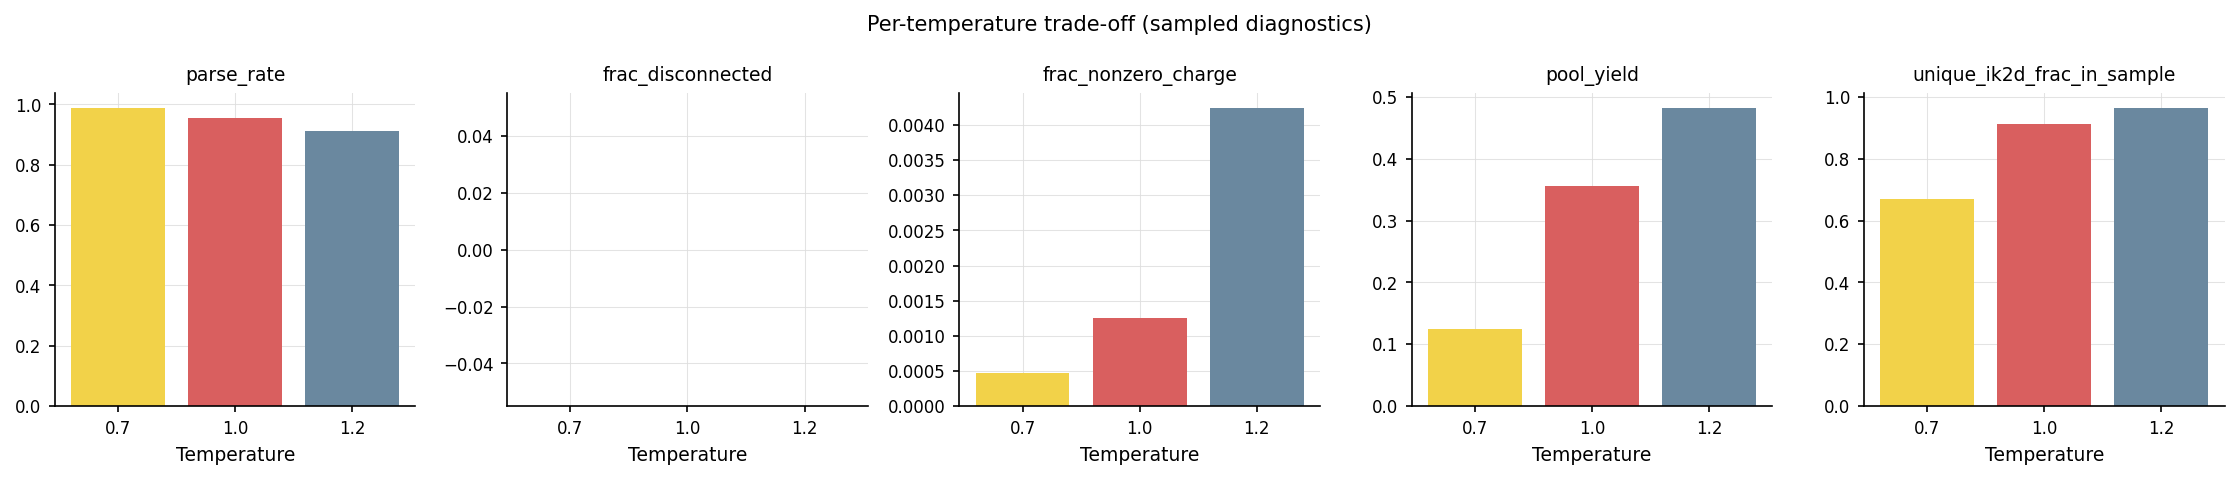

In [4]:
TEMPS = [0.7, 1.0, 1.2]
N_RAW_PER_TEMP = 15000

per_temp_rows = []
for temp in TEMPS:
    shards_t = sorted(S4_DIR.glob(f'samples/temp_{temp:.2f}/shard_*.parquet'))
    n_raw_temp = sum(pq.read_metadata(p).num_rows for p in shards_t)
    rng = np.random.RandomState(int(temp * 100))
    take_shards = list(rng.choice(shards_t, size=min(5, len(shards_t)), replace=False))
    n_per_shard = max(1, N_RAW_PER_TEMP // 5)
    dfs = []
    for p in take_shards:
        df = pd.read_parquet(p, columns=['smiles', 'log_likelihood'])
        dfs.append(df.sample(n=min(n_per_shard, len(df)), random_state=rng))
    df_temp = pd.concat(dfs, ignore_index=True)

    mols = df_temp['smiles'].map(Chem.MolFromSmiles)
    parse_mask = mols.notna()
    valid = df_temp[parse_mask].reset_index(drop=True)
    valid_mols = mols[parse_mask].reset_index(drop=True)
    charges = valid_mols.map(Chem.GetFormalCharge)
    heavy = valid_mols.map(lambda m: m.GetNumHeavyAtoms())
    iks = valid_mols.map(lambda m: Chem.MolToInchiKey(m)[:14] if m is not None else None)
    n_pool_temp = int((buckets['temperature'].round(2) == round(temp, 2)).sum())

    per_temp_rows.append({
        'temperature': temp,
        'n_raw': n_raw_temp,
        'n_pool_attributed': n_pool_temp,
        'pool_yield': n_pool_temp / n_raw_temp,
        'parse_rate': float(parse_mask.mean()),
        'frac_disconnected': float(valid['smiles'].str.contains(r'\.').mean()) if len(valid) else float('nan'),
        'frac_nonzero_charge': float((charges != 0).mean()) if len(charges) else float('nan'),
        'mean_heavy_atoms': float(heavy.mean()) if len(heavy) else float('nan'),
        'mean_log_likelihood': float(valid['log_likelihood'].mean()) if len(valid) else float('nan'),
        'unique_ik2d_frac_in_sample': iks.nunique() / max(1, len(iks)),
    })
df_per_temp = pd.DataFrame(per_temp_rows).set_index('temperature')
display(df_per_temp.round(4))

metrics = ['parse_rate', 'frac_disconnected', 'frac_nonzero_charge', 'pool_yield', 'unique_ik2d_frac_in_sample']
fig, axes = plt.subplots(1, len(metrics), figsize=(3.0 * len(metrics), 3.2), sharey=False)
for ax, metric in zip(axes, metrics):
    ax.bar([str(t) for t in df_per_temp.index], df_per_temp[metric], color=[POOL_COLOR, S4_COLOR, PUBCHEM_COLOR])
    ax.set_title(metric, fontsize=9)
    ax.set_xlabel('Temperature')
    _despine(ax)
fig.suptitle('Per-temperature trade-off (sampled diagnostics)', fontsize=10)
fig.tight_layout()
_save(fig, 'per_temp_tradeoff')
plt.show()

## 2 — Diversity: novelty + scaffold count + internal Tanimoto

In [5]:
queries = pd.read_parquet(S4_DIR / 'extract_unique_mols.parquet')
print(f'MSG queries (all folds): {len(queries):,}')
print('fold counts:'); print(queries["fold"].value_counts())

# Pool 2D-InChIKey ∩ MSG queries (across all folds).
msg_iks_all = set(queries['inchikey_2d'])
msg_iks_train = set(queries.loc[queries['fold'] == 'train', 'inchikey_2d'])
msg_iks_valtest = set(queries.loc[queries['fold'].isin(['val', 'test']), 'inchikey_2d'])

novel_mask_all = ~buckets['inchikey_2d'].isin(msg_iks_all)
novel_mask_valtest = ~buckets['inchikey_2d'].isin(msg_iks_valtest)
print(f'pool size: {len(buckets):,}')
print(f'novel vs ALL MSG queries: {int(novel_mask_all.sum()):,} ({novel_mask_all.mean()*100:.2f}%)')
print(f'novel vs MSG val+test only: {int(novel_mask_valtest.sum()):,} ({novel_mask_valtest.mean()*100:.2f}%)  '
      f'<-- leakage-clean indicator; should be very close to 100% because finetune used only MSG-train')
print(f'overlap with MSG-train: {int(buckets["inchikey_2d"].isin(msg_iks_train).sum()):,}')
print(f'overlap with MSG-val+test: {int(buckets["inchikey_2d"].isin(msg_iks_valtest).sum()):,}')

MSG queries (all folds): 28,936
fold counts:
fold
train    22755
val       3184
test      2997
Name: count, dtype: int64


pool size: 64,205,194
novel vs ALL MSG queries: 64,191,792 (99.98%)
novel vs MSG val+test only: 64,205,050 (100.00%)  <-- leakage-clean indicator; should be very close to 100% because finetune used only MSG-train


overlap with MSG-train: 13,258
overlap with MSG-val+test: 144


In [6]:
rng = np.random.RandomState(0)
sample_for_scaffold = buckets.sample(n=min(50_000, len(buckets)), random_state=rng)


def _scaffold(smi):
    m = Chem.MolFromSmiles(smi)
    if m is None: return None
    try:
        return MurckoScaffold.MurckoScaffoldSmiles(mol=m, includeChirality=False)
    except Exception:
        return None


scaffolds = sample_for_scaffold['smiles'].map(_scaffold).dropna()
n_unique_scaffolds = scaffolds.nunique()
print(f'unique Bemis-Murcko scaffolds in {len(sample_for_scaffold):,}-mol pool sample: '
      f'{n_unique_scaffolds:,} ({n_unique_scaffolds/len(sample_for_scaffold)*100:.1f}%)')

unique Bemis-Murcko scaffolds in 50,000-mol pool sample: 37,684 (75.4%)


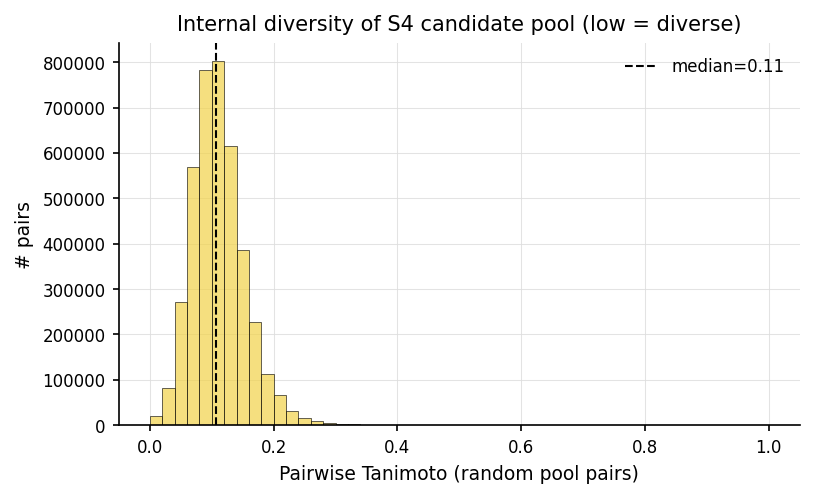

internal Tanimoto: median=0.106 mean=0.111 p10=0.061 p90=0.165


In [7]:
sample_a = buckets.sample(n=min(2000, len(buckets)), random_state=np.random.RandomState(0))
sample_b = buckets.sample(n=min(2000, len(buckets)), random_state=np.random.RandomState(1))
fps_a = [AllChem.GetMorganFingerprintAsBitVect(Chem.MolFromSmiles(s), 2, nBits=2048) for s in sample_a['smiles']]
fps_b = [AllChem.GetMorganFingerprintAsBitVect(Chem.MolFromSmiles(s), 2, nBits=2048) for s in sample_b['smiles']]
sims = np.asarray([BulkTanimotoSimilarity(q, fps_b) for q in fps_a]).flatten()
fig, ax = plt.subplots(figsize=(5.5, 3.4))
ax.hist(sims, bins=np.linspace(0, 1, 51), color=POOL_COLOR, alpha=0.7, edgecolor='black', linewidth=0.4)
ax.axvline(np.median(sims), color='black', linestyle='--', linewidth=1, label=f'median={np.median(sims):.2f}')
ax.set_xlabel('Pairwise Tanimoto (random pool pairs)')
ax.set_ylabel('# pairs'); ax.set_title('Internal diversity of S4 candidate pool (low = diverse)')
ax.legend(frameon=False); _despine(ax); fig.tight_layout()
_save(fig, 'pool_internal_tanimoto'); plt.show()
print(f'internal Tanimoto: median={np.median(sims):.3f} mean={sims.mean():.3f} p10={np.percentile(sims,10):.3f} p90={np.percentile(sims,90):.3f}')

## 2a — Pool chemical-quality sanity (disconnected / charge / elements)

=== POOL CHEMICAL QUALITY SANITY ===
  sampled rows                       : 50000
  parses via RDKit                   : 50000
  parse failures                     : 0
  disconnected (".")                 : 0
  % disconnected                     : 0.0
  charge == 0                        : 49839
  charge == +1                       : 116
  charge == -1                       : 44
  charge other (|q| >= 2)            : 1
  % non-zero charge                  : 0.322
  unique chemical elements           : 9
  mean heavy atoms                   : 26.82
  median heavy atoms                 : 26.0
  p90 heavy atoms                    : 36.0
  mean MW (Da)                       : 381.6
  median MW (Da)                     : 373.1

Element histogram (top 15 by atom count):
     C     992,985  (74.04%)
     O     180,862  (13.49%)
     N     124,594  ( 9.29%)
     S      15,442  ( 1.15%)
     F      12,657  ( 0.94%)
    Cl      10,788  ( 0.80%)
    Br       2,500  ( 0.19%)
     P         796  ( 

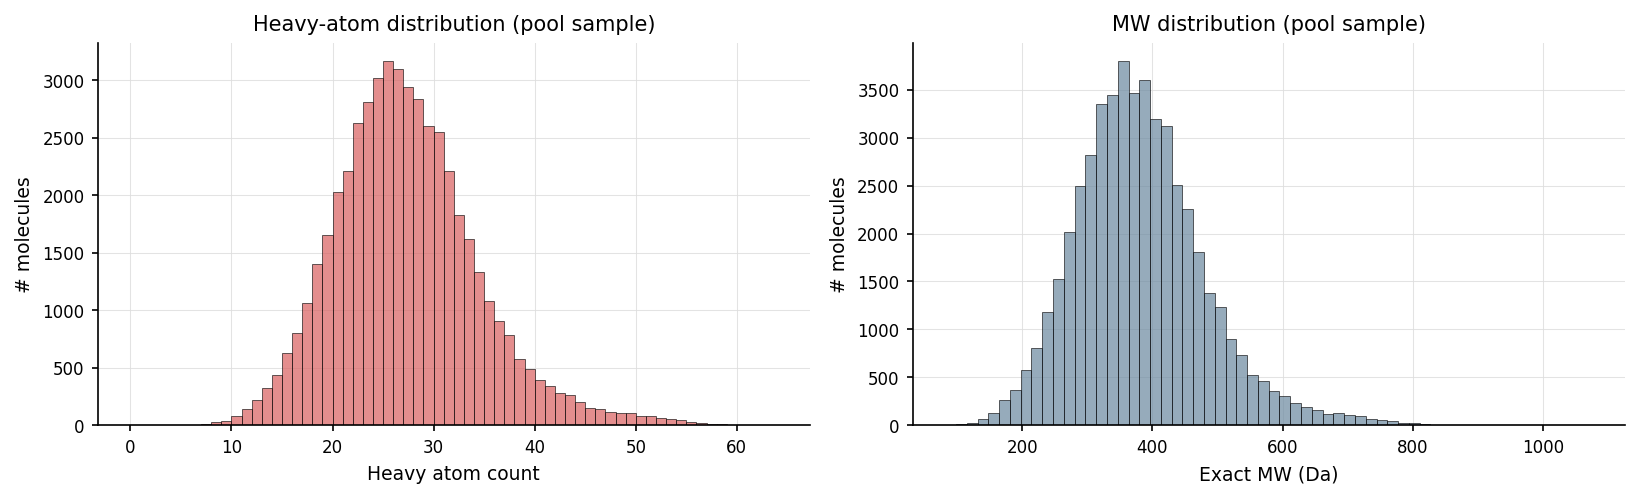

In [8]:
POOL_QUALITY_N = 50_000
qual_sample = buckets.sample(n=min(POOL_QUALITY_N, len(buckets)), random_state=np.random.RandomState(0)).reset_index(drop=True)
n = len(qual_sample)
n_dot = int(qual_sample['smiles'].str.contains(r'\.').sum())

mols = qual_sample['smiles'].map(Chem.MolFromSmiles)
parse_ok = mols.notna()
mols_v = mols[parse_ok]
charges = mols_v.map(Chem.GetFormalCharge)
heavy = mols_v.map(lambda m: m.GetNumHeavyAtoms())
mw = mols_v.map(lambda m: rdMolDescriptors.CalcExactMolWt(m))

n_parse_fail = int((~parse_ok).sum())
n_charge_zero = int((charges == 0).sum())
n_charge_pos1 = int((charges == 1).sum())
n_charge_neg1 = int((charges == -1).sum())
n_charge_other = int(((charges != 0) & (charges != 1) & (charges != -1)).sum())

elements = Counter()
for m in mols_v:
    for atom in m.GetAtoms():
        elements[atom.GetSymbol()] += 1
n_uniq_elements = len(elements)

quality = {
    'sampled rows': n,
    'parses via RDKit': n - n_parse_fail,
    'parse failures': n_parse_fail,
    'disconnected (".")': n_dot,
    '% disconnected': round(n_dot / n * 100, 3),
    'charge == 0': n_charge_zero,
    'charge == +1': n_charge_pos1,
    'charge == -1': n_charge_neg1,
    'charge other (|q| >= 2)': n_charge_other,
    '% non-zero charge': round((n - n_charge_zero) / max(1, len(mols_v)) * 100, 3),
    'unique chemical elements': n_uniq_elements,
    'mean heavy atoms': round(float(heavy.mean()), 2),
    'median heavy atoms': float(heavy.median()),
    'p90 heavy atoms': float(np.percentile(heavy, 90)),
    'mean MW (Da)': round(float(mw.mean()), 1),
    'median MW (Da)': round(float(mw.median()), 1),
}
print('=== POOL CHEMICAL QUALITY SANITY ===');
for k, v in quality.items(): print(f'  {k:35s}: {v}')
print(); print('Element histogram (top 15 by atom count):')
for sym, cnt in elements.most_common(15):
    print(f'  {sym:>4}  {cnt:>10,}  ({cnt / sum(elements.values()) * 100:5.2f}%)')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.4))
ax1.hist(heavy, bins=np.arange(0, max(60, heavy.max()) + 2), color=S4_COLOR, alpha=0.7, edgecolor='black', linewidth=0.4)
ax1.set_xlabel('Heavy atom count'); ax1.set_ylabel('# molecules'); ax1.set_title('Heavy-atom distribution (pool sample)')
_despine(ax1)
ax2.hist(mw, bins=60, color=PUBCHEM_COLOR, alpha=0.7, edgecolor='black', linewidth=0.4)
ax2.set_xlabel('Exact MW (Da)'); ax2.set_ylabel('# molecules'); ax2.set_title('MW distribution (pool sample)')
_despine(ax2)
fig.tight_layout(); _save(fig, 'pool_quality_distribution'); plt.show()

## 3 — Per-formula and per-mass bucket-size distribution

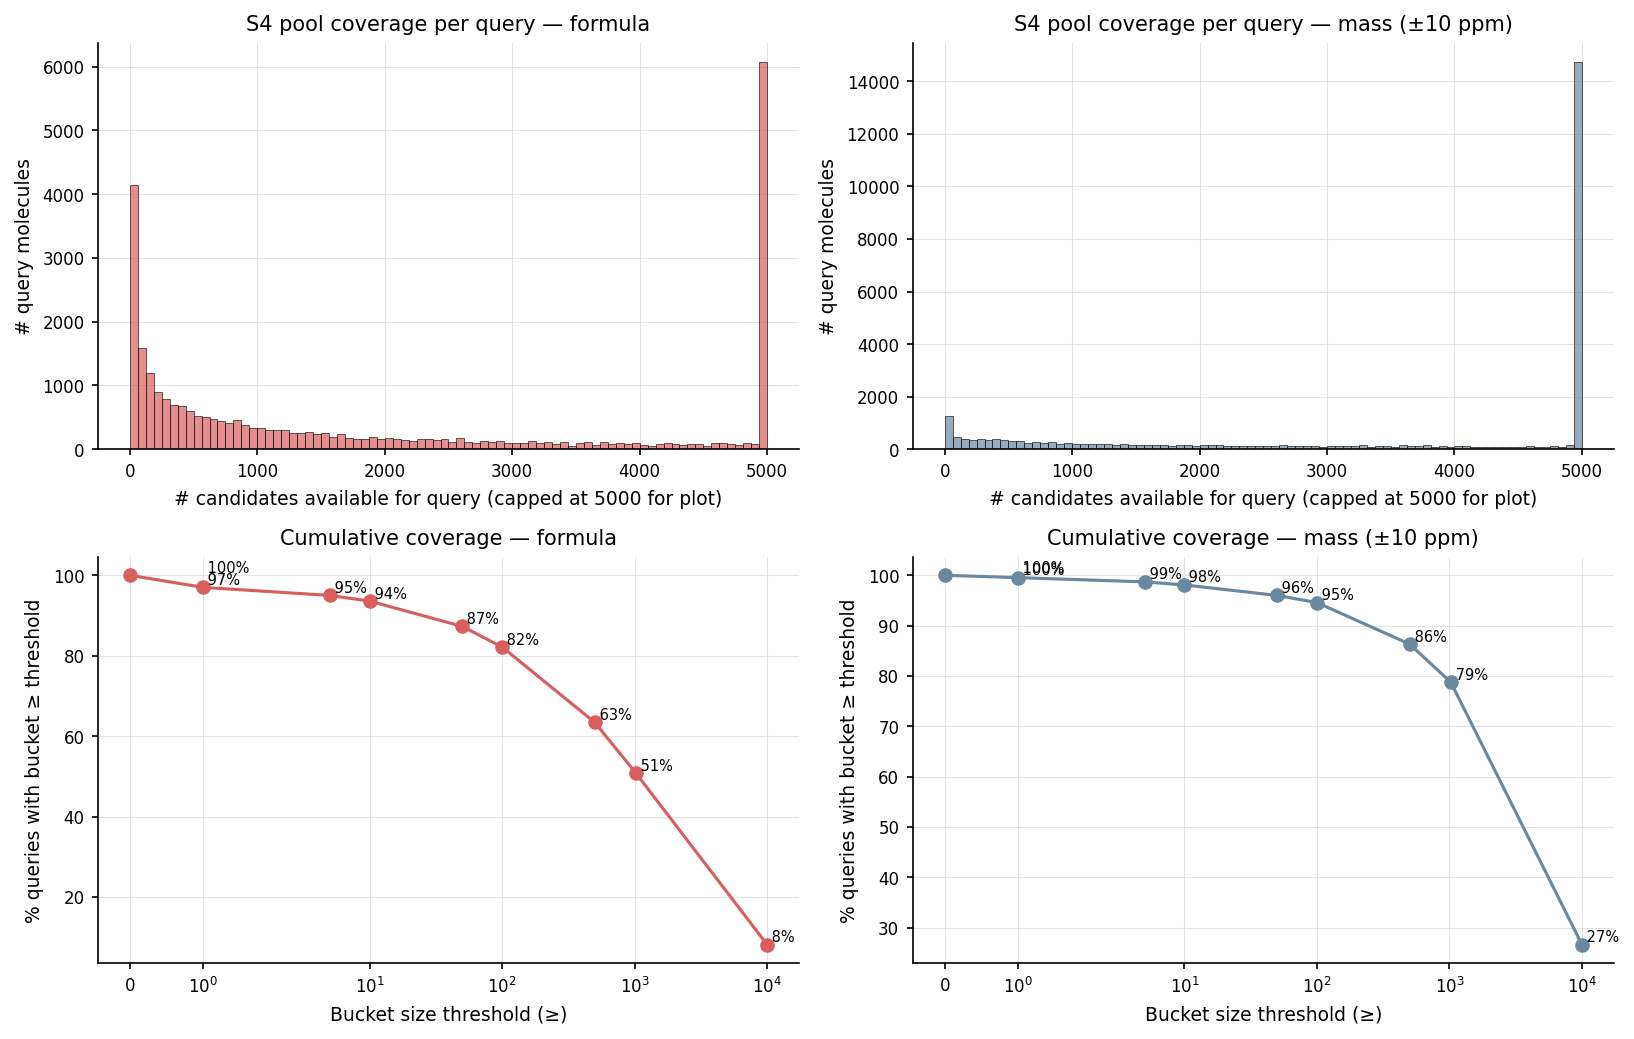

Formula: queries with empty bucket: 872 (3.01%)
Mass:    queries with empty bucket: 135 (0.47%)


In [9]:
# Per-formula bucket size for each query.
bucket_sizes_formula = buckets.groupby('formula').size()
queries_w_formula = queries.assign(pool_size=queries['formula'].map(bucket_sizes_formula).fillna(0).astype(int))

# Per-mass bucket size for each query (binary search over sorted pool masses).
pool_masses = np.sort(buckets['exact_mass'].to_numpy())
PPM = 10
def _count_in_mass_window(q_mass):
    tol = q_mass * PPM * 1e-6
    lo = np.searchsorted(pool_masses, q_mass - tol, side='left')
    hi = np.searchsorted(pool_masses, q_mass + tol, side='right')
    return int(hi - lo)

queries_w_mass = queries.assign(pool_size=queries['exact_mass'].map(_count_in_mass_window).astype(int))

fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for ax, (qw, mode, color) in zip(axes[0], [(queries_w_formula, 'formula', S4_COLOR), (queries_w_mass, 'mass (±10 ppm)', PUBCHEM_COLOR)]):
    ax.hist(np.clip(qw['pool_size'], 0, 5000), bins=80, color=color, alpha=0.7, edgecolor='black', linewidth=0.4)
    ax.set_xlabel(f'# candidates available for query (capped at 5000 for plot)')
    ax.set_ylabel('# query molecules')
    ax.set_title(f'S4 pool coverage per query — {mode}')
    _despine(ax)
thresholds = [0, 1, 5, 10, 50, 100, 500, 1024, 10000]
for ax, (qw, mode, color) in zip(axes[1], [(queries_w_formula, 'formula', S4_COLOR), (queries_w_mass, 'mass (±10 ppm)', PUBCHEM_COLOR)]):
    covered = [(qw['pool_size'] >= t).mean() * 100 for t in thresholds]
    ax.plot(thresholds, covered, 'o-', color=color)
    ax.set_xscale('symlog'); ax.set_xlabel('Bucket size threshold (≥)')
    ax.set_ylabel('% queries with bucket ≥ threshold'); ax.set_title(f'Cumulative coverage — {mode}')
    for t, p in zip(thresholds, covered):
        ax.text(max(t, 1), p, f' {p:.0f}%', fontsize=7, va='bottom')
    _despine(ax)
fig.tight_layout(); _save(fig, 'bucket_coverage'); plt.show()

print(f'Formula: queries with empty bucket: {int((queries_w_formula["pool_size"] == 0).sum()):,} '
      f'({(queries_w_formula["pool_size"] == 0).mean()*100:.2f}%)')
print(f'Mass:    queries with empty bucket: {int((queries_w_mass["pool_size"] == 0).sum()):,} '
      f'({(queries_w_mass["pool_size"] == 0).mean()*100:.2f}%)')

## 3a — Qualitative examples: random queries → 4 candidates each (formula-based)

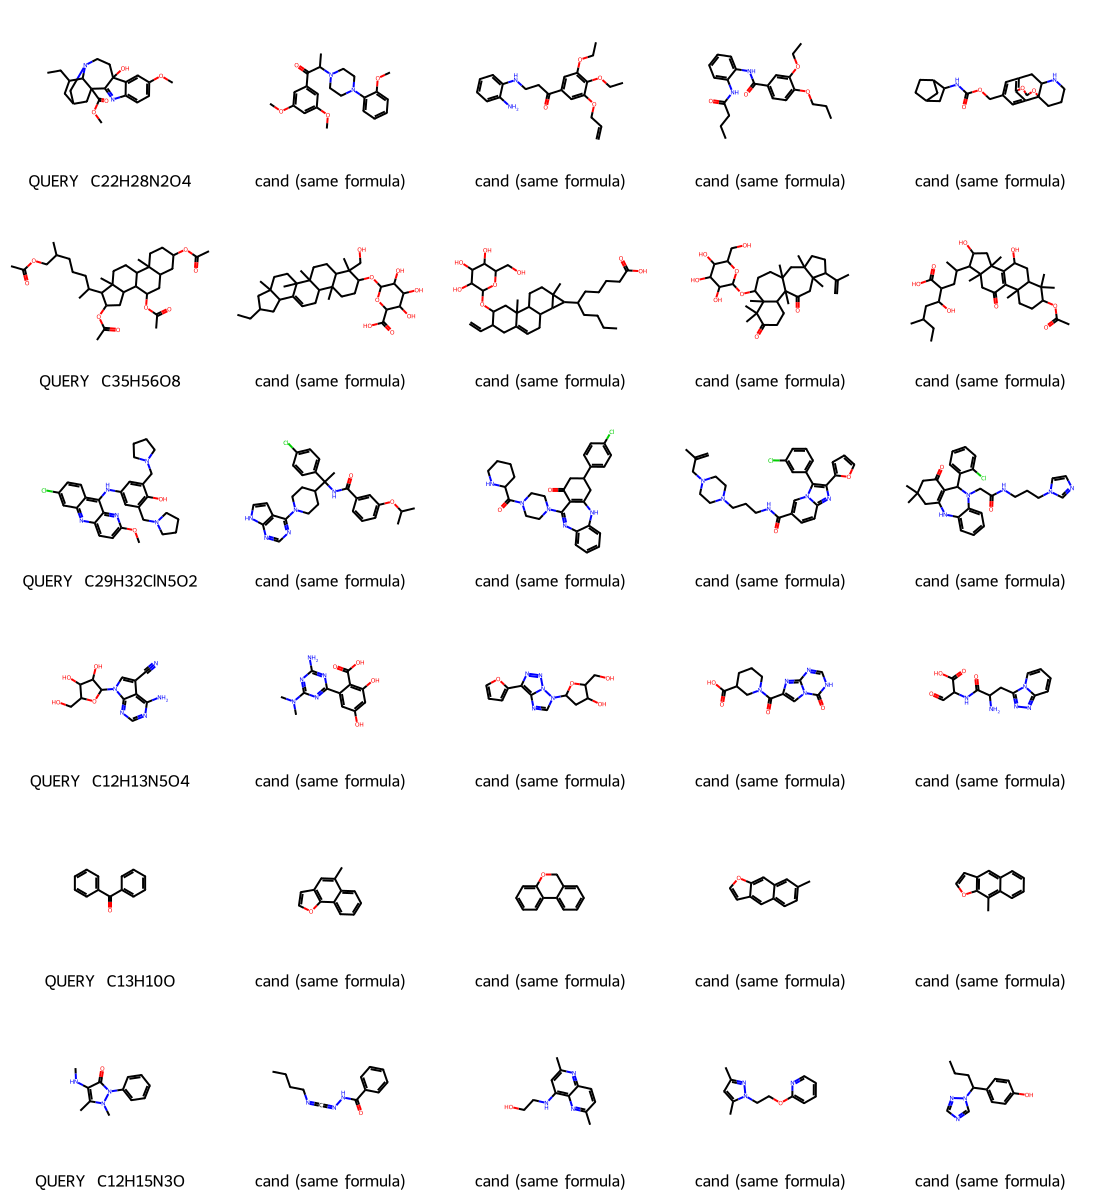

In [10]:
with S4_FORMULA_JSON.open() as f:
    s4_formula = json.load(f)

N_EX_QUERIES = 6; N_CAND_PER = 4
rng = np.random.RandomState(42)
ok_keys = [q for q in s4_formula if len(s4_formula[q]) >= N_CAND_PER + 1]
example_qs = list(rng.choice(ok_keys, size=min(N_EX_QUERIES, len(ok_keys)), replace=False))

mols_grid, legends = [], []
for q in example_qs:
    qm = Chem.MolFromSmiles(q)
    others = [c for c in s4_formula[q][1:] if c != q]
    chosen = list(rng.choice(others, size=min(N_CAND_PER, len(others)), replace=False))
    cmols = [Chem.MolFromSmiles(c) for c in chosen]
    qf = rdMolDescriptors.CalcMolFormula(qm) if qm else '?'
    mols_grid.append(qm); legends.append(f'QUERY  {qf}')
    for cm in cmols:
        mols_grid.append(cm); legends.append('cand (same formula)')

img = MolsToGridImage(mols_grid, molsPerRow=N_CAND_PER + 1, subImgSize=(220, 200), legends=legends, returnPNG=True)
png_bytes = img.data if hasattr(img, 'data') else (img if isinstance(img, (bytes, bytearray)) else None)
if png_bytes:
    (FIG_DIR / 'qualitative_formula.png').write_bytes(png_bytes)
display(_IPImage(png_bytes) if png_bytes else img)

## 3b — Qualitative examples: random queries → 4 candidates each (mass-based, ±10 ppm)

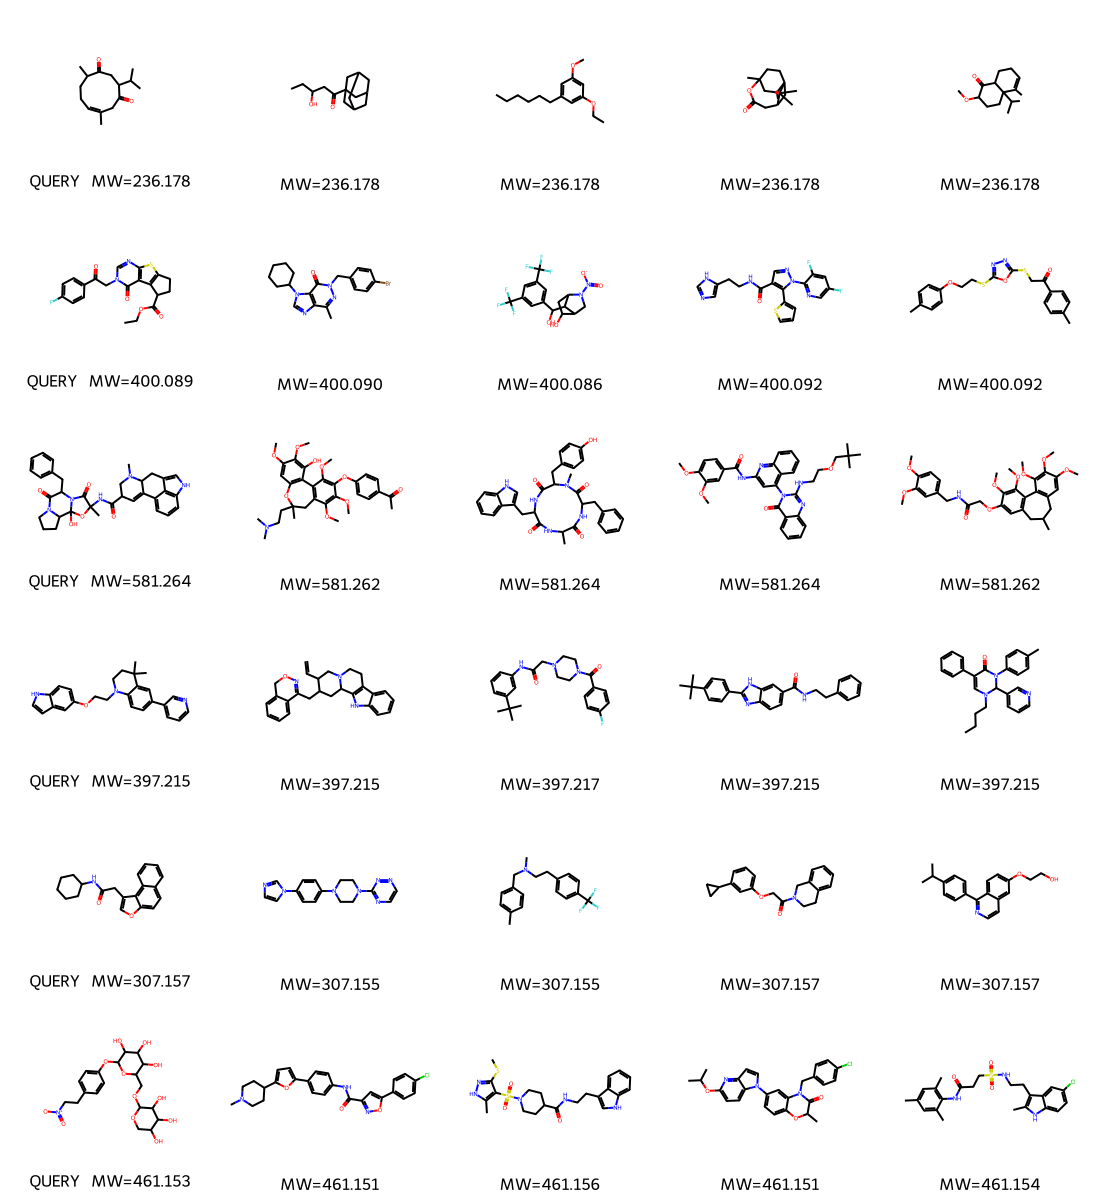

In [11]:
with S4_MASS_JSON.open() as f:
    s4_mass = json.load(f)

rng = np.random.RandomState(7)
ok_keys_m = [q for q in s4_mass if len(s4_mass[q]) >= N_CAND_PER + 1]
example_qs_m = list(rng.choice(ok_keys_m, size=min(N_EX_QUERIES, len(ok_keys_m)), replace=False))

mols_grid_m, legends_m = [], []
for q in example_qs_m:
    qm = Chem.MolFromSmiles(q)
    others = [c for c in s4_mass[q][1:] if c != q]
    chosen = list(rng.choice(others, size=min(N_CAND_PER, len(others)), replace=False))
    cmols = [Chem.MolFromSmiles(c) for c in chosen]
    qmass = rdMolDescriptors.CalcExactMolWt(qm) if qm else 0.0
    mols_grid_m.append(qm); legends_m.append(f'QUERY  MW={qmass:.3f}')
    for cm in cmols:
        cmass = rdMolDescriptors.CalcExactMolWt(cm) if cm else 0.0
        mols_grid_m.append(cm); legends_m.append(f'MW={cmass:.3f}')

img_m = MolsToGridImage(mols_grid_m, molsPerRow=N_CAND_PER + 1, subImgSize=(220, 200), legends=legends_m, returnPNG=True)
png_bytes_m = img_m.data if hasattr(img_m, 'data') else (img_m if isinstance(img_m, (bytes, bytearray)) else None)
if png_bytes_m:
    (FIG_DIR / 'qualitative_mass.png').write_bytes(png_bytes_m)
display(_IPImage(png_bytes_m) if png_bytes_m else img_m)

## 4 — Tanimoto query → candidates (per-formula)

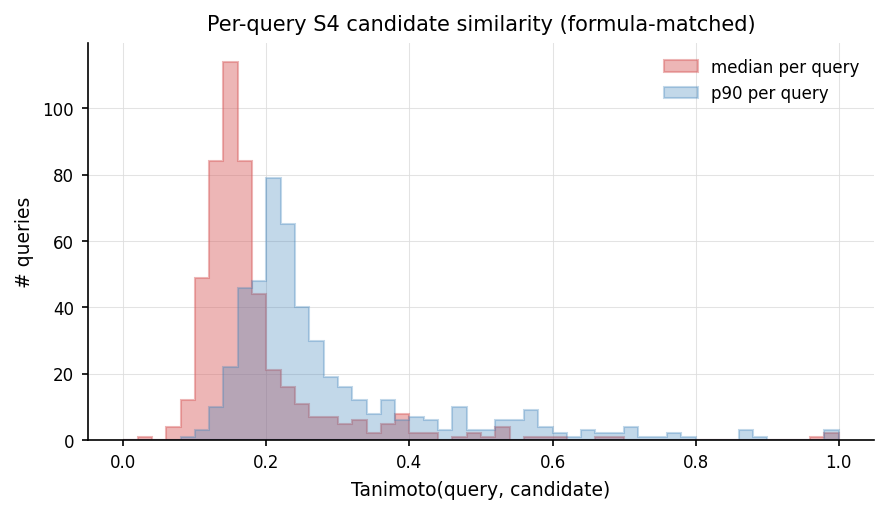

queries analysed: 500
median-Tanimoto: median=0.158 p10=0.115 p90=0.286


In [12]:
N_Q = 500; N_C_PER_Q = 200
rng = np.random.RandomState(0)
non_empty_keys = [q for q in s4_formula if len(s4_formula[q]) >= 2]
subset = rng.choice(non_empty_keys, size=min(N_Q, len(non_empty_keys)), replace=False)

med_per_q, p90_per_q = [], []
for q in subset:
    qm = Chem.MolFromSmiles(q)
    if qm is None: continue
    qfp = AllChem.GetMorganFingerprintAsBitVect(qm, 2, nBits=2048)
    cands = s4_formula[q][1:]
    if len(cands) > N_C_PER_Q:
        cands = list(rng.choice(cands, size=N_C_PER_Q, replace=False))
    cfps = []
    for s in cands:
        m = Chem.MolFromSmiles(s)
        if m is not None:
            cfps.append(AllChem.GetMorganFingerprintAsBitVect(m, 2, nBits=2048))
    if not cfps: continue
    s = np.asarray(BulkTanimotoSimilarity(qfp, cfps))
    med_per_q.append(float(np.median(s)))
    p90_per_q.append(float(np.percentile(s, 90)))

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.hist(med_per_q, bins=np.linspace(0, 1, 51), histtype='stepfilled', alpha=0.45, color=S4_COLOR, edgecolor=S4_COLOR, label='median per query')
ax.hist(p90_per_q, bins=np.linspace(0, 1, 51), histtype='stepfilled', alpha=0.30, color='#377EB8', edgecolor='#377EB8', label='p90 per query')
ax.set_xlabel('Tanimoto(query, candidate)'); ax.set_ylabel('# queries')
ax.set_title('Per-query S4 candidate similarity (formula-matched)')
ax.legend(frameon=False); _despine(ax); fig.tight_layout()
_save(fig, 'tanimoto_query_to_candidates_formula'); plt.show()
print(f'queries analysed: {len(med_per_q):,}')
print(f'median-Tanimoto: median={np.median(med_per_q):.3f} p10={np.percentile(med_per_q,10):.3f} p90={np.percentile(med_per_q,90):.3f}')

## 5 — Side-by-side comparison vs existing MassSpecGym candidate sets

Compare the new 1024-capped S4 candidates with the existing 256-capped PubChem-derived candidates.

,n_entries,median_len,mean_len,p90_len,max_len,trivial_only_query (len=1),trivial_pct
name,,,,,,,
S4 formula 1024-cap,28936,512,380.880702,512,512,878,3.034
PubChem formula 256-cap,32010,256,212.060856,256,256,128,0.400
S4 mass ±10ppm 1024-cap,28936,512,467.914190,512,512,136,0.470
PubChem mass ±10ppm 256-cap,32010,256,252.845954,256,256,0,0.000


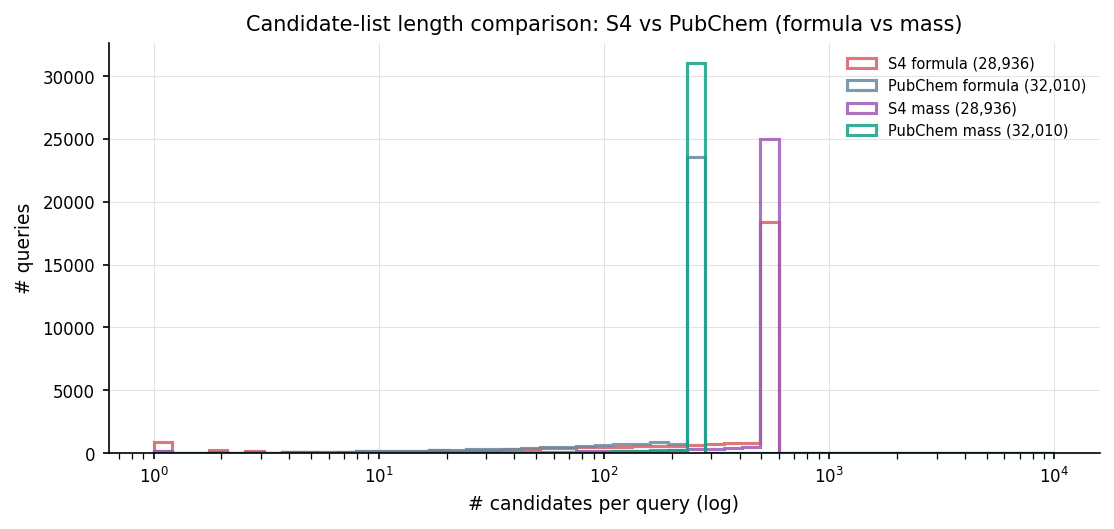

In [13]:
with PUBCHEM_FORMULA_JSON.open() as f: pubchem_formula = json.load(f)
with PUBCHEM_MASS_JSON.open() as f:    pubchem_mass    = json.load(f)

def _stats(d, label):
    L = np.asarray([len(v) for v in d.values()])
    n1 = int((L == 1).sum())
    return {
        'name': label, 'n_entries': len(d),
        'median_len': int(np.median(L)), 'mean_len': float(L.mean()),
        'p90_len': int(np.percentile(L, 90)), 'max_len': int(L.max()),
        'trivial_only_query (len=1)': n1,
        'trivial_pct': round(n1 / len(L) * 100, 3),
    }

import pandas as pd
df_cmp = pd.DataFrame([
    _stats(s4_formula, 'S4 formula 1024-cap'),
    _stats(pubchem_formula, 'PubChem formula 256-cap'),
    _stats(s4_mass, 'S4 mass ±10ppm 1024-cap'),
    _stats(pubchem_mass, 'PubChem mass ±10ppm 256-cap'),
]).set_index('name')
display(df_cmp)

fig, ax = plt.subplots(figsize=(7.5, 3.6))
bins = np.logspace(0, 4, 50)
for L, color, label in [
    (np.asarray([len(v) for v in s4_formula.values()]), S4_COLOR, f'S4 formula ({len(s4_formula):,})'),
    (np.asarray([len(v) for v in pubchem_formula.values()]), PUBCHEM_COLOR, f'PubChem formula ({len(pubchem_formula):,})'),
    (np.asarray([len(v) for v in s4_mass.values()]), '#9B59B6', f'S4 mass ({len(s4_mass):,})'),
    (np.asarray([len(v) for v in pubchem_mass.values()]), '#16A085', f'PubChem mass ({len(pubchem_mass):,})'),
]:
    ax.hist(L, bins=bins, histtype='step', linewidth=1.5, alpha=0.85, color=color, label=label)
ax.set_xscale('log')
ax.set_xlabel('# candidates per query (log)'); ax.set_ylabel('# queries')
ax.set_title('Candidate-list length comparison: S4 vs PubChem (formula vs mass)')
ax.legend(frameon=False, fontsize=7); _despine(ax)
fig.tight_layout(); _save(fig, 'list_length_compare'); plt.show()

## 5a — Queries with zero or few candidates (both variants)

Show example MSG queries that S4 could not produce formula or mass matches for.

queries with zero formula match: 878 (3.03%)
queries with zero mass match:    136 (0.47%)

Example queries with no formula match:


,smiles,formula
0,Cc1cc2c(c(O)c1-c1c(C)cc3c(c1O)C(=CNc1cc(C(C)(C...,C58H72N2O8
1,CC(C)C12SSC3(C(=O)N1C)C(O)C1(C45c6ccccc6NC4N4C...,C32H32N6O7S4
2,CC1(C(=O)O)CCC2(C(=O)OC3OC(CO)C(O)C(O)C3O)CCC3...,C47H74O19
3,Cc1ncc(COP(=O)(O)O)c(CN(CCN(CC(=O)O)Cc2c(COP(=...,C22H32N4O14P2
4,C=C1CC23CCC4C(C)(C(=O)OC5OC(CO)C(O)C(O)C5O)CCC...,C44H70O23
5,COc1cc(OC2OC(COC3OC(CO)C(O)C(OC4OC(COC5OC(CO)C...,C39H52O25
6,Nc1nccc(Oc2ccc(NC(=O)c3cn(COP(=O)(O)O)cc(-c4cc...,C24H18ClF2N4O7P
7,CCCCCCCCC=CCCCCCCCC(=O)OCC(COP(=O)(O)OCC(O)CO)...,C42H79O10P
8,CC1CN2CC(C)OB(O1)OC(C)C2,C9H18BNO3
9,CCCCCC(=O)OC1CC2CC(C(=O)NCCCCN=C(N)N)N(C(=O)C(...,C41H64N6O14


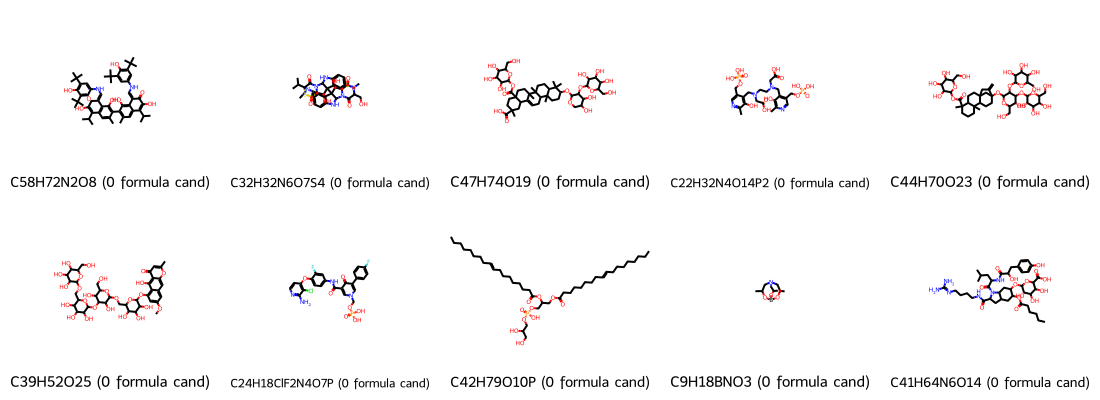

In [14]:
def _count(d):
    return {q: len(v) for q, v in d.items()}

cnt_form = _count(s4_formula)
cnt_mass = _count(s4_mass)
keys_all = list(s4_formula.keys())

n_zero_f = sum(1 for q in keys_all if cnt_form[q] == 1)
n_zero_m = sum(1 for q in keys_all if cnt_mass[q] == 1)
print(f'queries with zero formula match: {n_zero_f:,} ({n_zero_f/len(keys_all)*100:.2f}%)')
print(f'queries with zero mass match:    {n_zero_m:,} ({n_zero_m/len(keys_all)*100:.2f}%)')

rng = np.random.RandomState(0)
zero_f_keys = [q for q in keys_all if cnt_form[q] == 1]
if zero_f_keys:
    samp = list(rng.choice(zero_f_keys, size=min(10, len(zero_f_keys)), replace=False))
    print()
    print('Example queries with no formula match:')
    rows = []
    for q in samp:
        m = Chem.MolFromSmiles(q)
        f = rdMolDescriptors.CalcMolFormula(m) if m else '?'
        rows.append({'smiles': q, 'formula': f})
    display(pd.DataFrame(rows))
    mols = [Chem.MolFromSmiles(s) for s in samp]
    legends = [f'{rdMolDescriptors.CalcMolFormula(Chem.MolFromSmiles(s)) if Chem.MolFromSmiles(s) else "?"} (0 formula cand)' for s in samp]
    img_z = MolsToGridImage(mols, molsPerRow=5, subImgSize=(220, 200), legends=legends, returnPNG=True)
    pb = img_z.data if hasattr(img_z, 'data') else None
    if pb:
        (FIG_DIR / 'queries_zero_formula.png').write_bytes(pb)
        display(_IPImage(pb))

## 6 — Caveats / sanity checks

In [15]:
# Formula consistency spot-check.
rng = np.random.RandomState(0)
sample_keys = rng.choice(list(s4_formula.keys()), size=500, replace=False)
n_match_f = n_total_f = 0
n_misordered = 0
for q in sample_keys:
    cands = s4_formula[q]
    if cands[0] != q:
        n_misordered += 1; continue
    qm = Chem.MolFromSmiles(q)
    if qm is None: continue
    qf = rdMolDescriptors.CalcMolFormula(qm)
    others = cands[1:][:50]
    for c in others:
        cm = Chem.MolFromSmiles(c)
        if cm is None: continue
        n_total_f += 1
        if rdMolDescriptors.CalcMolFormula(cm) == qf:
            n_match_f += 1

# Mass consistency spot-check.
sample_keys_m = rng.choice(list(s4_mass.keys()), size=500, replace=False)
n_match_m = n_total_m = 0
PPM = 10
for q in sample_keys_m:
    cands = s4_mass[q]
    qm = Chem.MolFromSmiles(q)
    if qm is None: continue
    q_mass = rdMolDescriptors.CalcExactMolWt(qm)
    tol = q_mass * PPM * 1e-6
    others = cands[1:][:50]
    for c in others:
        cm = Chem.MolFromSmiles(c)
        if cm is None: continue
        n_total_m += 1
        if abs(rdMolDescriptors.CalcExactMolWt(cm) - q_mass) <= tol:
            n_match_m += 1

print(f'formula spot-check — query-at-index-0: {500-n_misordered}/500')
print(f'formula spot-check — match: {n_match_f:,}/{n_total_f:,} = {n_match_f/max(n_total_f,1)*100:.2f}%')
print(f'mass spot-check    — match (±{PPM} ppm): {n_match_m:,}/{n_total_m:,} = {n_match_m/max(n_total_m,1)*100:.2f}%')

formula spot-check — query-at-index-0: 500/500
formula spot-check — match: 23,116/23,116 = 100.00%
mass spot-check    — match (±10 ppm): 24,156/24,156 = 100.00%


## 6a — Per-bucket 2D-InChIKey uniqueness sanity (both variants)

In [16]:
N_BUCKETS = 100; MAX_PER_BUCKET = 500
rng = np.random.RandomState(0)

def _check_unique(d, label):
    non_trivial = [q for q in d if len(d[q]) >= 2]
    samp = list(rng.choice(non_trivial, size=min(N_BUCKETS, len(non_trivial)), replace=False))
    n_dup = 0
    for q in samp:
        cands = d[q]
        if len(cands) > MAX_PER_BUCKET + 1:
            cands = [cands[0]] + list(rng.choice(cands[1:], size=MAX_PER_BUCKET, replace=False))
        iks = []
        for s in cands:
            m = Chem.MolFromSmiles(s)
            if m is None: continue
            try: iks.append(Chem.MolToInchiKey(m)[:14])
            except Exception: pass
        if iks and len(iks) != len(set(iks)):
            n_dup += 1
    print(f'{label}: buckets checked={len(samp)}, with InChIKey duplicates={n_dup}')

_check_unique(s4_formula, 'S4 formula')
_check_unique(s4_mass, 'S4 mass')

S4 formula: buckets checked=100, with InChIKey duplicates=0


S4 mass: buckets checked=100, with InChIKey duplicates=0


## 7 — Summary table

In [17]:
summary = {
    'MSG queries (all folds)': len(queries),
    'pool size (post canon + dedup)': n_pool,
    'unique formulas in pool': int(buckets['formula'].nunique()),
    'pool overlap with MSG-train': int(buckets['inchikey_2d'].isin(msg_iks_train).sum()),
    'pool overlap with MSG val+test': int(buckets['inchikey_2d'].isin(msg_iks_valtest).sum()),
    'S4 formula JSON — n_queries': len(s4_formula),
    'S4 formula JSON — trivial fallback (len=1)': sum(1 for v in s4_formula.values() if len(v) == 1),
    'S4 mass JSON — n_queries': len(s4_mass),
    'S4 mass JSON — trivial fallback (len=1)': sum(1 for v in s4_mass.values() if len(v) == 1),
}
display(pd.DataFrame([summary]).T.rename(columns={0: 'value'}))

,value
MSG queries (all folds),28936
pool size (post canon + dedup),64205194
unique formulas in pool,1470580
pool overlap with MSG-train,13258
pool overlap with MSG val+test,144
S4 formula JSON — n_queries,28936
S4 formula JSON — trivial fallback (len=1),878
S4 mass JSON — n_queries,28936
S4 mass JSON — trivial fallback (len=1),136
